# Student Scores Analysis

**Previous Step**: [cleaning.ipynb](cleaning.ipynb)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, kruskal, ttest_ind
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
df = pd.read_csv('Scores.csv', sep=';', decimal=',')
df.head()
df['parental.level.of.education'].unique()

<StringArray>
['high school', 'associate's degree', 'bachelor's degree', 'master's degree']
Length: 4, dtype: str

In [3]:
edu_order = ["high school", "associate's degree",
             "bachelor's degree", "master's degree"]
edu_labels = ["High School", "Associate's", "Bachelor's", "Master's"]
 
# Short labels for plots
edu_short = {
    "high school":        "High School",
    "associate's degree": "Associate's",
    "bachelor's degree":  "Bachelor's",
    "master's degree":    "Master's"
}

In [4]:
 
df['edu'] = pd.Categorical(
    df['parental.level.of.education'],
    categories=edu_order,
    ordered=True
)
print(df['edu'].head(10))

0    high school
1    high school
2    high school
3    high school
4    high school
5    high school
6    high school
7    high school
8    high school
9    high school
Name: edu, dtype: category
Categories (4, str): ['high school' < 'associate's degree' < 'bachelor's degree' < 'master's degree']


In [5]:
print("="* 100)
print("1. step1: descriptive stats by parent educ level")
print("="* 100)

for subject in ['language', 'math']:
    print(f"{subject.upper()}")
    print(" " + "-"* 50)
    sub = df[df['subject'] == subject]
    desc = sub.groupby('edu', observed=True)['score'].agg(

    
        Count='count',
        Mean = 'mean',
        Std  = 'std',
        Median = 'median',  
        Min  = 'min',
        Max  = 'max'
        ).round(2)
    desc.index = edu_labels
    print(desc.to_string())
    print("\n")



1. step1: descriptive stats by parent educ level
LANGUAGE
 --------------------------------------------------
             Count   Mean    Std  Median   Min    Max
High School    156  63.53  13.40    65.0  19.5   99.5
Associate's    177  70.02  14.21    72.0  34.5  100.0
Bachelor's      94  72.06  14.27    73.0  40.0  100.0
Master's        59  75.53  13.55    76.0  44.0  100.0


MATH
 --------------------------------------------------
             Count   Mean    Std  Median   Min    Max
High School    156  62.24  14.04    63.0  23.0   94.0
Associate's    177  67.81  15.24    66.0  26.0  100.0
Bachelor's      94  68.44  15.05    67.0  29.0  100.0
Master's        59  69.75  15.15    73.0  40.0   95.0




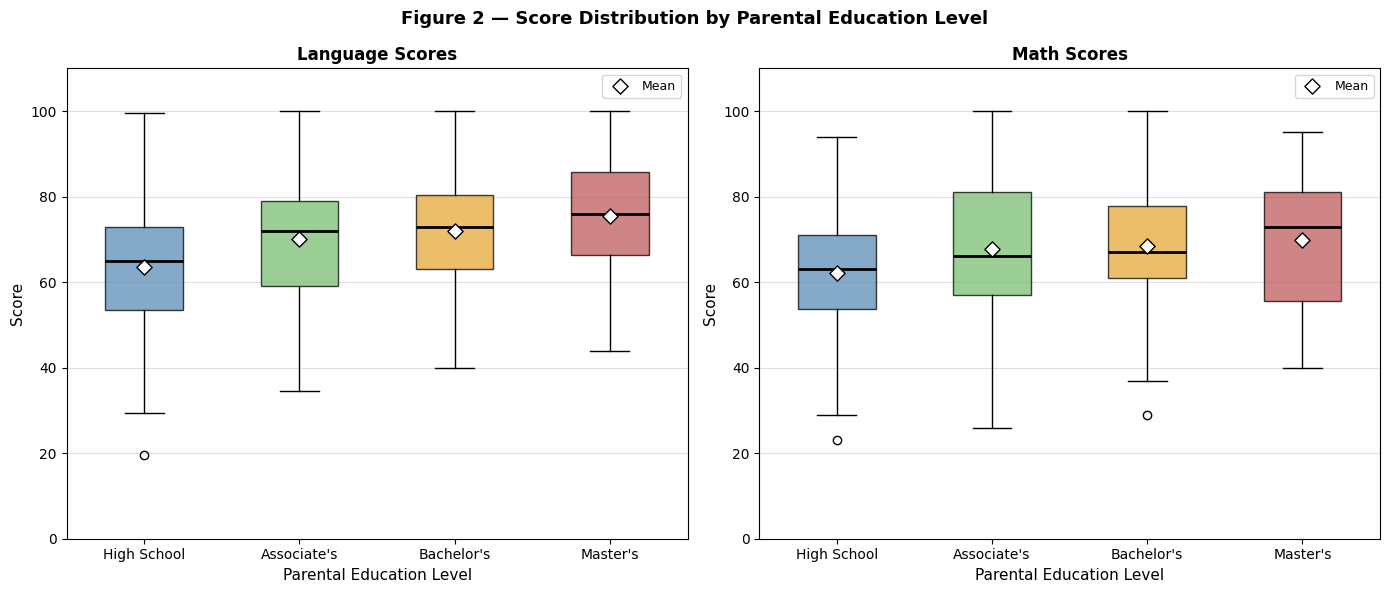

  → Figure 2 saved: boxplot_education.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 2 — Score Distribution by Parental Education Level',
             fontsize=13, fontweight='bold')
 
colors = ['#5B8DB8', '#7BBF72', '#E8A838', '#C05C5C']
 
for idx, subject in enumerate(['language', 'math']):
    ax = axes[idx]
    sub = df[df['subject'] == subject].copy()
    sub['edu_label'] = sub['edu'].map(edu_short)
 
    groups = [
        sub[sub['edu'] == lvl]['score'].values
        for lvl in edu_order
    ]
 
    bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
 
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
 
    # Add mean markers
    for i, grp in enumerate(groups):
        ax.scatter(i+1, np.mean(grp), marker='D', color='white',
                   edgecolor='black', s=60, zorder=5, label='Mean' if i==0 else '')
 
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels(edu_labels, fontsize=10)
    ax.set_title(f'{subject.title()} Scores', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11)
    ax.set_xlabel('Parental Education Level', fontsize=11)
    ax.set_ylim(0, 110)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.4)
 
plt.tight_layout()
plt.savefig('boxplot_education.png', dpi=150, bbox_inches='tight')
plt.show()
print("  → Figure 2 saved: boxplot_education.png")
 

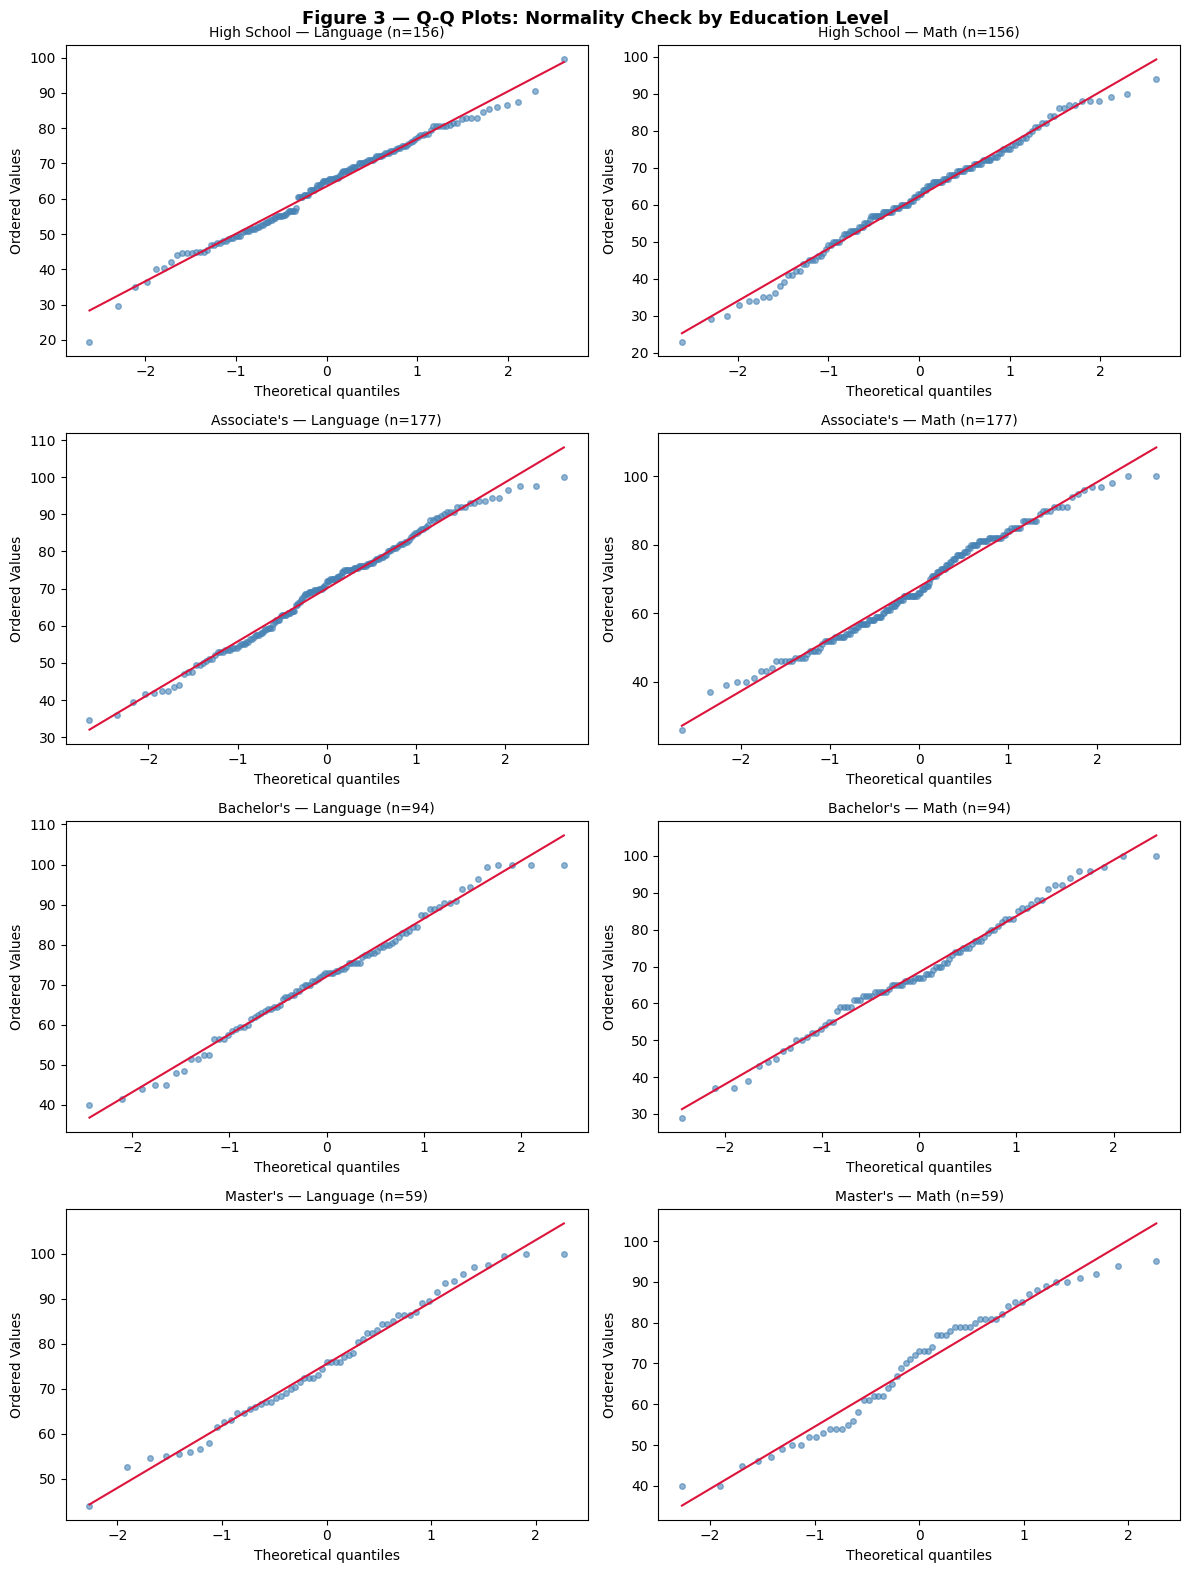

  → Figure 3 saved: qq_plots_education.png


In [7]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
fig.suptitle('Figure 3 — Q-Q Plots: Normality Check by Education Level',
             fontsize=13, fontweight='bold')
 
for row, edu_lvl in enumerate(edu_order):
    for col, subject in enumerate(['language', 'math']):
        ax = axes[row, col]
        data = df[(df['subject'] == subject) &
                  (df['edu'] == edu_lvl)]['score']
        stats.probplot(data, dist="norm", plot=ax)
        ax.set_title(f"{edu_short[edu_lvl]} — {subject.title()} (n={len(data)})",
                     fontsize=10)
        ax.get_lines()[0].set(color='steelblue', markersize=4, alpha=0.6)
        ax.get_lines()[1].set(color='crimson', linewidth=1.5)
 
plt.tight_layout()
plt.savefig('qq_plots_education.png', dpi=150, bbox_inches='tight')
plt.show()
print("  → Figure 3 saved: qq_plots_education.png")

In [8]:
print("\n" + "="*70)
print("step4 one way anova + tukey hsd posthoc")
print("\n" + "="*70)
for subject in ['language', 'math']:
    print(f"\n {subject.upper()}")
    print("\n" + "="*70)
    sub = df[df['subject'] == subject]
    groups = [
        sub[sub['edu'] == lvl]['score'].values 
        for lvl in edu_order
        ]
    lev_stat, p_levene = stats.levene(*groups)
    print(f"\n levene test for variance hommogenity across 4 groups :")
    print(f"       F = {lev_stat:.4f} | p = {p_levene:.4f} ")
    print(f"       Equa variance: {'YES' if p_levene > 0.05 else 'NO'}")
    



step4 one way anova + tukey hsd posthoc


 LANGUAGE


 levene test for variance hommogenity across 4 groups :
       F = 0.1693 | p = 0.9171 
       Equa variance: YES

 MATH


 levene test for variance hommogenity across 4 groups :
       F = 1.2748 | p = 0.2824 
       Equa variance: YES


In [9]:
#ONE WAY ANOVA
f_stat, p_anova = stats.f_oneway(*groups)
all_scores  = sub['score'].values
grand_mean  = all_scores.mean()
ss_between  = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_total    = sum((x - grand_mean)**2 for x in all_scores)
eta_sq      = ss_between / ss_total
eta_meaning = ("small"  if eta_sq < 0.06 else
                   "medium" if eta_sq < 0.14 else "large")

print(f"\n  📊 One-Way ANOVA:")

print(f"     H₀: μ_HS = μ_Assoc = μ_Bach = μ_Master  (all means equal)")
print(f"     H₁: At least one group mean differs  (α = 0.05)")
print(f"     • F({len(groups)-1}, {len(all_scores)-len(groups)}) = {f_stat:.3f}")
p_disp = "p < 0.0001" if p_anova < 0.0001 else f"p = {p_anova:.4f}"
print(f"     • {p_disp}")
print(f"     • η² = {eta_sq:.4f} → {eta_meaning} effect size")
print(f"       ({eta_sq*100:.1f}% of score variance explained by parental education)")
 
if p_anova < 0.05:
    print(f"     ✅ SIGNIFICANT — at least one group differs → running Tukey HSD")
else:
    print(f"     ❌ Not significant — no evidence of difference across groups")
    print("  " + "─"*60)
    




  📊 One-Way ANOVA:
     H₀: μ_HS = μ_Assoc = μ_Bach = μ_Master  (all means equal)
     H₁: At least one group mean differs  (α = 0.05)
     • F(3, 482) = 6.223
     • p = 0.0004
     • η² = 0.0373 → small effect size
       (3.7% of score variance explained by parental education)
     ✅ SIGNIFICANT — at least one group differs → running Tukey HSD


In [10]:
# ── Tukey HSD ────────────────────────────────────────────────
tukey = pairwise_tukeyhsd(
        endog=sub['score'],
        groups=sub['edu'],
        alpha=0.05
    )
 
print(f"\n  🔍 Tukey HSD Post-hoc — Pairwise Comparisons:")
print(f"     {'Pair':<42} {'Mean Diff':>10} {'p-value':>10} {'Significant':>12}")
print(f"     {'─'*76}")
 
tukey_df = pd.DataFrame(
        data=tukey._results_table.data[1:],
        columns=tukey._results_table.data[0]
    )
 
for _, row in tukey_df.iterrows():
        g1   = edu_short.get(str(row['group1']), str(row['group1']))
        g2   = edu_short.get(str(row['group2']), str(row['group2']))
        pair = f"{g1} vs {g2}"
        diff = float(row['meandiff'])
        pval = float(row['p-adj'])
        sig  = "✅ YES" if row['reject'] else "❌ no"
        p_show = "< 0.0001" if pval < 0.0001 else f"{pval:.4f}"
        print(f"     {pair:<42} {diff:>+10.2f} {p_show:>10} {sig:>12}")
 
print("  " + "─"*60)


  🔍 Tukey HSD Post-hoc — Pairwise Comparisons:
     Pair                                        Mean Diff    p-value  Significant
     ────────────────────────────────────────────────────────────────────────────
     Associate's vs Bachelor's                       +0.62     0.9877         ❌ no
     Associate's vs High School                      -5.57     0.0037        ✅ YES
     Associate's vs Master's                         +1.93     0.8217         ❌ no
     Bachelor's vs High School                       -6.19     0.0079        ✅ YES
     Bachelor's vs Master's                          +1.31     0.9512         ❌ no
     High School vs Master's                         +7.50     0.0055        ✅ YES
  ────────────────────────────────────────────────────────────


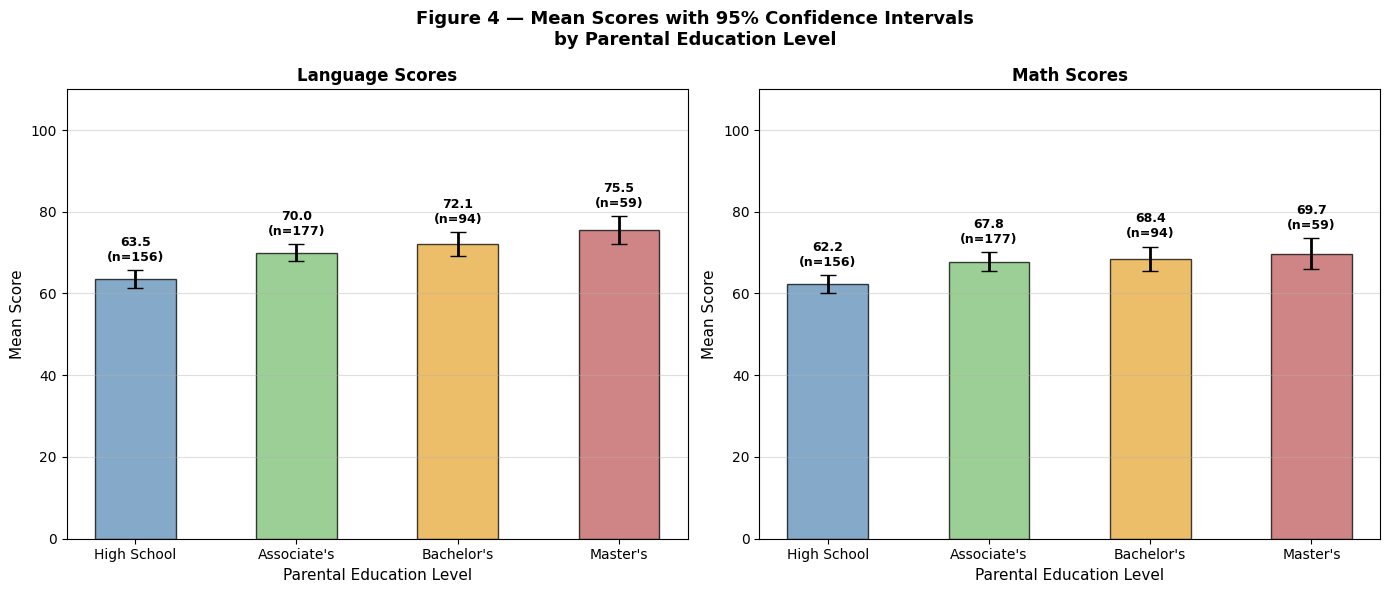

  → Figure 4 saved: means_education.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 4 — Mean Scores with 95% Confidence Intervals\nby Parental Education Level',
             fontsize=13, fontweight='bold')
 
for idx, subject in enumerate(['language', 'math']):
    ax = axes[idx]
    sub = df[df['subject'] == subject]
 
    means, cis, ns = [], [], []
    for lvl in edu_order:
        grp  = sub[sub['edu'] == lvl]['score']
        m    = grp.mean()
        se   = grp.sem()
        ci   = 1.96 * se
        means.append(m)
        cis.append(ci)
        ns.append(len(grp))
 
    x = np.arange(len(edu_labels))
    ax.bar(x, means, color=colors, alpha=0.75, edgecolor='black', width=0.5)
    ax.errorbar(x, means, yerr=cis, fmt='none',
                color='black', capsize=6, linewidth=2)
 
    for i, (m, n) in enumerate(zip(means, ns)):
        ax.text(i, m + cis[i] + 1.5, f'{m:.1f}\n(n={n})',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
 
    ax.set_xticks(x)
    ax.set_xticklabels(edu_labels, fontsize=10)
    ax.set_title(f'{subject.title()} Scores', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Score', fontsize=11)
    ax.set_xlabel('Parental Education Level', fontsize=11)
    ax.set_ylim(0, 110)
    ax.grid(axis='y', alpha=0.4)
 
plt.tight_layout()
plt.savefig('means_education.png', dpi=150, bbox_inches='tight')
plt.show()
print("  → Figure 4 saved: means_education.png")